# Supervised spillover metrics

The `supervised` (`sp`) module provides metrics to assess how well the single cell profiles in the spatial transcriptomics dataset correlate with a reference scRNA-seq dataset. To compute these metrics, we load both datasets and transfer labels from the reference to the query dataset.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import spatialdata as sd

import segtraq as st

# Define color palette and groups for plotting
col_celltype = {
    "T": "#fb8072",
    "B": "#bc80bd",
    "macro": "#910290",
    "dendritic": "#fdb462",
    "mast": "#959059",
    "perivas": "#fed9a6",
    "endo": "#a6cee3",
    "myoepi": "#2782bb",
    "DCIS1": "#3c7761",
    "DCIS2": "#66a61e",
    "tumor": "#66c2a5",
    "stromal": "#d45943",
    "Unknown": "#808080",
}

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: Fut

#### Transfer labels from scRNA-seq to spatial transcriptomics
First, we load a spatial transcriptomics dataset as well as an annotated single-cell RNAseq dataset. We then use the `run_label_transfer()` function to transfer cell type labels from the scRNAseq data onto our spatial transcriptomics dataset. We can then plot our cell types spatially.

In [2]:
# Load spatial transcriptomics dataset
st_data_path = Path("/g/huber/users/lazic/src/SegTraQ/tests/data/xenium_sdata.zarr")
sdata_10x_xenium = sd.read_zarr(st_data_path)

# Load scRNA-seq dataset
scRNAseq_data_path = Path("/g/huber/users/lazic/src/SegTraQ/tests/data/scRNAseq_ref.h5ad")
adata_ref = ad.read_h5ad(scRNAseq_data_path)

version mismatch: detected: RasterFormatV02, requested: FormatV04
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)


In [3]:
st.run_label_transfer(sdata_10x_xenium, adata_ref, celltype_key="celltype_major", inplace=True)

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/src/segtraq/utils.py:137: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ref_mean_df = counts_df.groupby("celltype").mean()
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/tmp/ipykernel_1348/4039217447.py:1: RuntimeWarning: Spatialdata table appears to contain raw counts. Counts will be log1p-transformed before running label transfer.
  st.run_label_transfer(sdata_10x_xenium, adata_ref, celltype_key="celltype_major", inplace=True)


Transferred cell-type labels are saved in the AnnData object at `adata.obs['transferred_celltype']` (one label per cell). The dominant cell type in the dataset is T cells (n=523).

Next, cell shapes can be plotted and colored by cell type based on a defined color palette. Some cells lack a transferred cell-type label (due to filtering low-count cells before label transfer); for compatibility with `spatialdata-plot`, we replace missing values (`NaN`) with "Unknown" before plotting.

In [4]:
# Replace NaN with Unknown
s = sdata_10x_xenium.tables["table"].obs["transferred_celltype"]
if pd.api.types.is_categorical_dtype(s):
    s = s.cat.add_categories(["Unknown"])

sdata_10x_xenium.tables["table"].obs["transferred_celltype_plot"] = s.fillna("Unknown")

labels = sdata_10x_xenium.tables["table"].obs["transferred_celltype_plot"].unique().astype(str).tolist()
cols = [col_celltype[lab] for lab in labels]

/tmp/ipykernel_1348/781573583.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/spatialdata.py:511: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cell_boundaries` already exists. Overwriting it in-memory.
  self

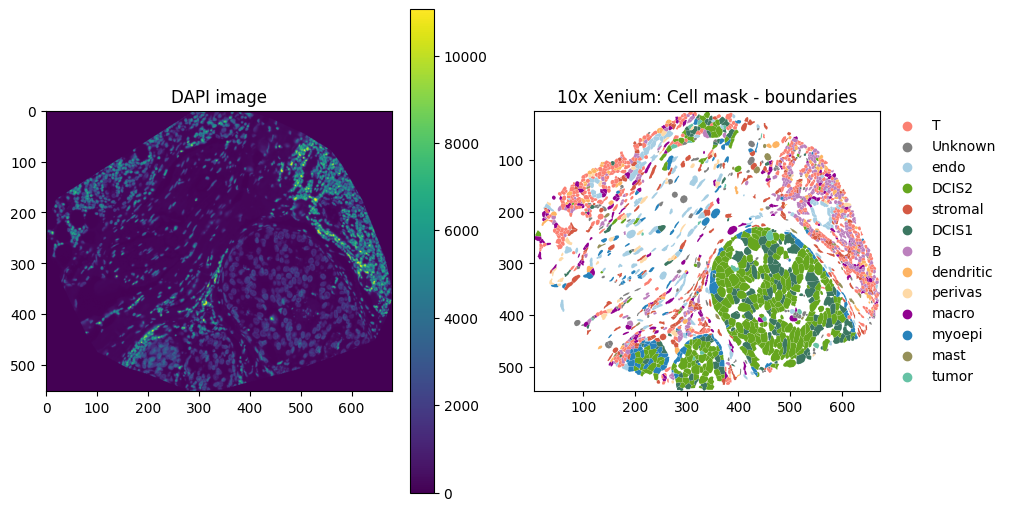

In [5]:
axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)[1].flatten()

# Dapi image
sdata_10x_xenium.pl.render_images("morphology_focus").pl.show(
    ax=axes[0], title="DAPI image", coordinate_systems="global"
)

# Plot - Cell boundaries
sdata_10x_xenium.tables["table"].obs["region"] = "cell_boundaries"
sdata_10x_xenium.set_table_annotates_spatialelement("table", region="cell_boundaries")

sdata_10x_xenium.pl.render_shapes(
    "cell_boundaries", color="transferred_celltype_plot", palette=cols, groups=labels
).pl.show(ax=axes[1], title="10x Xenium: Cell mask - boundaries", coordinate_systems="global")

Before we continue, we extract the `anndata` object from our `spatialdata` object, and perform both normalization and a log-transform on the expression matrix.

In [6]:
tbl = sdata_10x_xenium.tables["table"]
sc.pp.normalize_total(tbl, target_sum=1e4)
sc.pp.log1p(tbl)

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


#### Compute positive and negative markers (per cell type)

Some genes are only expressed by certain cell types. This means that we can compute which genes we do or do not see in specific cell types. We call these positive or negative markers.

Positive and negative markers per cell type are identified by computing, for each gene, the difference between its mean expression within the target cell type and its mean expression across all other cells, then selecting genes above the `q_pos` quantile as positive markers and below the `q_neg` quantile as negative markers. To enforce type specificity, genes that appear in at least a `t · n_celltypes` fraction of the per-type marker lists are removed separately for positives and negatives.

We will only consider genes common to the scRNA-seq and spatial transcriptomics dataset to reduce compute time.

In [7]:
# subsetting our spatial proteomics dataset to only contain genes that also appear in the scRNA-seq data
common_genes = tbl.var_names[tbl.var_names.isin(adata_ref.var_names)]
adata_ref = adata_ref[:, common_genes].copy()

In [8]:
# computing the positive and negative markers for each cell type
# the result is a dict with your cell type as keys (B, T, etc.) and another dict as values, which tell you the positive or negative markers for each cell type
markers = st.sp.get_ref_markers(adata_ref, cell_type_column="celltype_major", q_pos=0.95, q_neg=0.1, t=0.25)

Let's check our positive markers for B and T cells.

In [9]:
markers["B"]["positive"][:20]

['ACP5',
 'ADAM28',
 'ADAM8',
 'ADGRG5',
 'AIM2',
 'AMFR',
 'ANGPTL6',
 'ANKHD1',
 'ANKRD13A',
 'APOBEC3C',
 'APOBEC3F',
 'APOL3',
 'ATP2B1',
 'BANK1',
 'BCL11A',
 'BCL2',
 'BLK',
 'BLNK',
 'BRAF',
 'BTAF1']

In [10]:
markers["T"]["positive"][25:30]

['CD226', 'CD247', 'CD27', 'CD28', 'CD3D']

The first 20 positive markers in B cells include B-lineage signaling genes (BANK1, BLK, BLNK), supporting gens (BACH2, BCL11A, BCL2), genes upregulated downstream of BCR signaling (APOBEC3C/D/F) and ADAM28 reported in B-cell populations.

Among T cell positive markers, we find well-known T cell lienage markers and co-stimulatory receptors.

#### Find mutually exclusive marker pairs

Our next goal is to find pairs of markers that never occur together (they are "mutually exclusive", i.e. if one marker is seen in a cell, we expect the second marker not to be expressed in the same cell). We identify those pairs of genes on the scRNA-seq dataset.

Mutually exclusive gene pairs are identified by scanning each cell type’s positive markers, keeping genes expressed in >20% of that type but <5% of all other cells and retaining only genes that satisfy this criterion for a single type. It then returns all cross-type combinations of these type-unique genes as (gene1, gene2) pairs.

In [11]:
# computing pairs of mutually exclusive genes
mut_excl_marker_pairs = st.sp.get_mut_excl_markers(
    adata_ref,
    cell_type_column="celltype_major",
    markers=markers,
    pos_threshold=0.2,
    neg_threshold=0.05,
    max_codetect=0.01,
)

In [12]:
mut_excl_marker_pairs[10:20]

[('BLK', 'BMPR1B'),
 ('BLK', 'EREG'),
 ('BLK', 'MUC16'),
 ('BLK', 'PCDH10'),
 ('BLK', 'SCGB1D2'),
 ('CD19', 'BMPR1B'),
 ('CD19', 'EREG'),
 ('CD19', 'MUC16'),
 ('CD19', 'PCDH10'),
 ('CD19', 'SCGB1D2')]

#### Compute mutually exclusive co-expression rate (MECR) per gene pair

Now that we know which markers should never occur together, we can compute the mutually exclusive co-expression rate (MECR) on our spatial transcriptomics data.

The MECR per gene pair in the spatial transcriptomics dataset can be calculated using the `sp.compute_MECR()` method. The MECR measures how often two genes are co-detected relative to how often either is detected, i.e. `MECR = P(both>0) / P(g1>0 ∪ g2>0)`. An MECR of 0 means that the gene pair never co-occurred, which we would expect for our mutually exclusive markers. Non-zero values indicate that there might be some contamination going on.

In [13]:
# computing the MECR
mecr = st.sp.compute_MECR(sdata_10x_xenium, gene_pairs=mut_excl_marker_pairs)

# mecr is a dictionary
# let's look at the first 5 entries
for i, (k, v) in enumerate(mecr.items()):
    print(k, v)
    if i == 4:
        break

('AIM2', 'BMPR1B') 0.0
('AIM2', 'EREG') 0.0
('AIM2', 'MUC16') 0.0
('AIM2', 'PCDH10') 0.0
('AIM2', 'SCGB1D2') 0.0


For each gene pair, we now have an MECR value. Let's investigate the distribution of those values

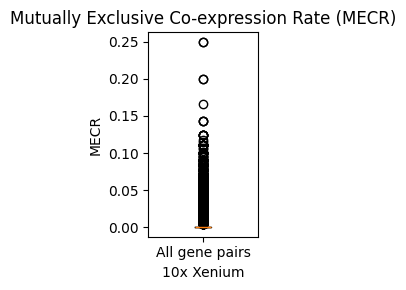

In [14]:
vals = list(mecr.values())

fig, ax = plt.subplots(figsize=(2, 3))
ax.boxplot([vals], vert=True)
ax.set_title("Mutually Exclusive Co-expression Rate (MECR)")
ax.set_xlabel("10x Xenium")
ax.set_ylabel("MECR")
ax.set_xticklabels(["All gene pairs"])
plt.tight_layout()
plt.show()

In [15]:
vals_nz = [x for x in vals if x > 0]  # non zero
print(f"{100 * (len(vals_nz) / len(vals)):.2f}% of gene pairs that should be mutually exclusive have a non-zero MECR.")
print(f"Median MECR = {np.median(vals_nz)}, variance = {np.var(vals_nz)}")

13.45% of gene pairs that should be mutually exclusive have a non-zero MECR.
Median MECR = 0.025, variance = 0.0004445663483411204


Over all gene pairs, the median MECR is zero, however 13% of the gene pairs found to be mutually exclusive in the reference scRNA-seq dataset have non-zero MECR with a median of 0.025.
To get a better picture of this effect, we can check the MECR per cell type. This will tell us if there are any cell type specific biases.

#### Computing the MECR for pairs of cell types

We can also compute the mutually exclusive genes for pairs of cell types. To do this, we once again use the function `sp.get_mut_excl_markers()`, but now we specify the `cell_types` parameter (which is a tuple of cell types).

In [36]:
# computing pairs of mutually exclusive genes
mut_excl_markers_b_t = st.sp.get_mut_excl_markers(
    adata_ref,
    cell_type_column="celltype_major",
    markers=markers,
    pos_threshold=0.2,
    neg_threshold=0.05,
    max_codetect=0.01,
    cell_types=("B", "T"),
)
mut_excl_markers_b_t[::10]

[('AIM2', 'BCL11B'),
 ('AIM2', 'LCK'),
 ('BANK1', 'ITK'),
 ('BLK', 'IL2RB'),
 ('CD19', 'GZMA'),
 ('CD22', 'CD8A'),
 ('CD79A', 'CD28'),
 ('CD79B', 'CD247'),
 ('FCRL1', 'CCR4'),
 ('FCRL2', 'BCL11B'),
 ('FCRL2', 'LCK'),
 ('FCRL5', 'ITK'),
 ('MS4A1', 'IL2RB'),
 ('PAX5', 'CCR4'),
 ('POU2AF1', 'BCL11B'),
 ('POU2AF1', 'LCK'),
 ('SCIMP', 'ITK'),
 ('TLR10', 'IL2RB'),
 ('TNFRSF13B', 'GZMA'),
 ('TNFRSF13C', 'CD8A')]

Now that we have mutually exclusive marker pairs for our B and T cells, we can once again compute the MECR, but now specific to B and T cells.

In [37]:
# computing the MECR
mecr = st.sp.compute_MECR(sdata_10x_xenium, gene_pairs=mut_excl_markers_b_t)

# mecr is a dictionary
# let's look at the first 5 entries
for i, (k, v) in enumerate(mecr.items()):
    print(k, v)
    if i == 4:
        break

('AIM2', 'BCL11B') 0.0
('AIM2', 'CCR4') 0.0
('AIM2', 'CD247') 0.0
('AIM2', 'CD28') 0.0
('AIM2', 'CD3G') 0.0


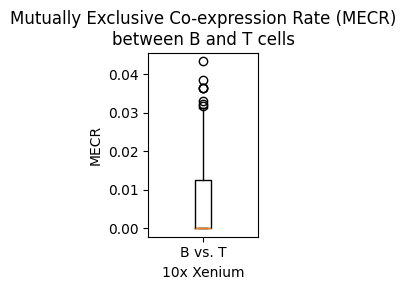

In [39]:
vals = list(mecr.values())

fig, ax = plt.subplots(figsize=(2, 3))
ax.boxplot([vals], vert=True)
ax.set_title("Mutually Exclusive Co-expression Rate (MECR)\nbetween B and T cells")
ax.set_xlabel("10x Xenium")
ax.set_ylabel("MECR")
ax.set_xticklabels(["B vs. T"])
plt.tight_layout()
plt.show()

In [ ]:
# TODO: need some better validation that this works here!

#### Evaluate positive and negative marker purity

From our MECR calculations, we know that there are some genes which co-occur when they shouldn't, hinting at some form of contamination. A next logical step would be to identify the cells where this is the case. To do this, we can calculate the marker purity for each cell.

Positive and negative marker purity in the spatial transcriptomics datasets can be computed via `sp.calculate_marker_purity()`. It evaluates, for each cell, how well its expected positive markers are among the cell’s top-expressed genes and how well the negative markers are not among those top genes, using a quantile/rank threshold based on the size of each marker list. From this it computes precision, recall, and F1 for both marker sets and combines them into a single “purity” score that rewards strong positive signal and penalizes negative signal. The output is a per-cell table of these metrics alongside the annotated cell type.

In [20]:
purity_df = st.sp.calculate_marker_purity(sdata_10x_xenium, celltype_column="transferred_celltype", markers=markers)
purity_df.head()

,positive_precision,positive_recall,positive_F1,negative_precision,negative_recall,negative_F1,F1_purity
cell_id,,,,,,,
bfdldgcn-1,0.145455,0.046512,0.070485,0.109091,0.011788,0.021277,0.131499
bfdlebgn-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
bfdlfpan-1,0.000000,0.000000,0.000000,0.166667,0.001965,0.003883,0.000000
bfdlgpib-1,0.148148,0.023256,0.040201,0.148148,0.007859,0.014925,0.077249
bfdljaab-1,0.230769,0.034884,0.060606,0.153846,0.007859,0.014953,0.114187


In [21]:
# add purity scores to AnnData observations
tbl.obs = tbl.obs.merge(
    purity_df.reset_index(),
    how="left",
    left_on="cell_id",
    right_on="cell_id",
)

/tmp/ipykernel_1348/626445013.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = df.groupby("transferred_celltype_plot")["F1_purity"].median().sort_values(ascending=False).index


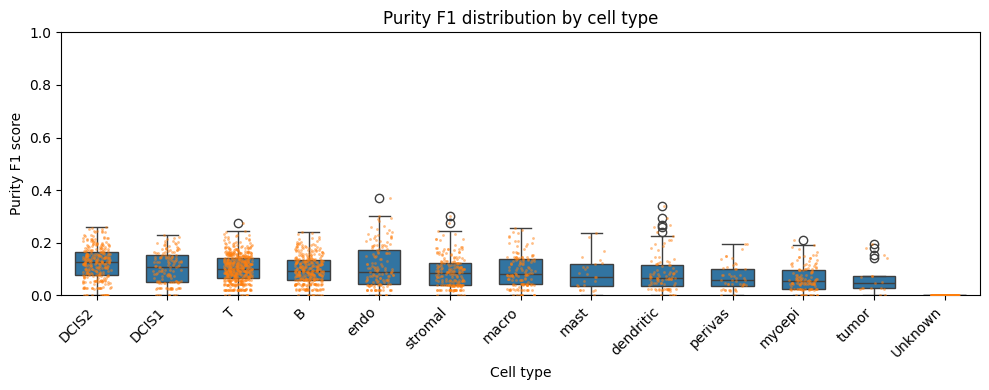

In [22]:
# plotting the distribution of the purity F1 score per cell type
df = tbl.obs[["transferred_celltype_plot", "F1_purity"]].dropna()

order = df.groupby("transferred_celltype_plot")["F1_purity"].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="transferred_celltype_plot", y="F1_purity", order=order, width=0.6)
sns.stripplot(data=df, x="transferred_celltype_plot", y="F1_purity", order=order, alpha=0.5, size=2, jitter=0.2)

plt.ylim(0, 1)
plt.xlabel("Cell type")
plt.ylabel("Purity F1 score")
plt.title("Purity F1 distribution by cell type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [23]:
# getting the median F1 purity score per cell type
df.groupby("transferred_celltype_plot")["F1_purity"].median()

/tmp/ipykernel_1348/2323935708.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("transferred_celltype_plot")["F1_purity"].median()


transferred_celltype_plot
B            0.091743
DCIS1        0.109256
DCIS2        0.125904
T            0.101747
dendritic    0.066127
endo         0.089415
macro        0.079807
mast         0.070758
myoepi       0.055468
perivas      0.057410
stromal      0.083164
tumor        0.048480
Unknown      0.000000
Name: F1_purity, dtype: float64

From the plot and the median values, we can see that the cell type "tumor" yields the lowest purity F1 score, while DCIS2 has the highest one. 

#### Neigbhorhood contamination

Let's check which cell types are responsible for this contamination. Use the `sp.calculate_contamination()` function to quantify directional “leakage” between cell types in spatial data: for each `ct` cell, it uses a spatial neighbors graph (computed with `squidpy`) to measure what share of ct-specific positive-marker signal appears inside neighboring `ct2` cells, then averages these fractions into a ct→ct2 matrix. 

Higher entries suggest spillover rather than true biology.

In [24]:
k_df, cont_df_diag, cont_df = st.sp.calculate_contamination(
    sdata_10x_xenium,
    markers=markers,
    celltype_column="transferred_celltype",
    cell_centroid_x_key="x_centroid",
    cell_centroid_y_key="y_centroid",
)

We can visualize the pairwise contamination between cell types in the form of a heatmap.

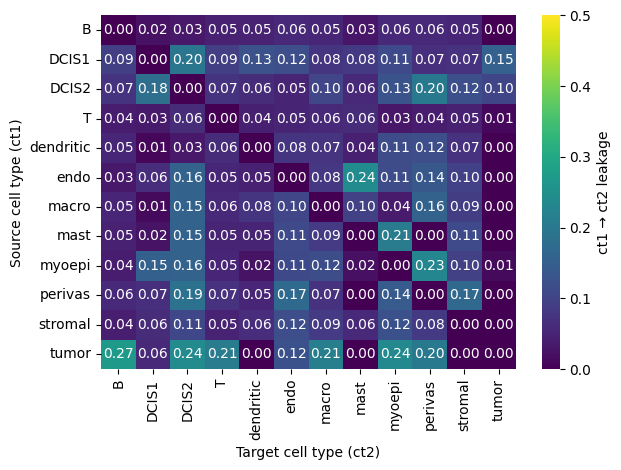

In [25]:
ax = sns.heatmap(
    cont_df_diag, vmin=0, vmax=0.5, cmap="viridis", annot=True, fmt=".2f", cbar_kws={"label": "ct1 → ct2 leakage"}
)
ax.set_xlabel("Target cell type (ct2)")
ax.set_ylabel("Source cell type (ct1)")
plt.tight_layout()

Comments from Daria: 

- I am not 100% sure how to interpret the heatmap above... can one compare between cell types, e.g. DCIS2 mostly contaminate into perivas and DCIS1... would have expected that they contaminated into myoepi, because they most often neighbor those... maybe don't divide by count of interactions??? - because then contamination from 1 interaction has the same weight as multiple interactions
- Contamination and purity for individual cell types do not seem to correlate. Strong correlation between purity and contamination isn’t guaranteed, since the two readouts measure different things:
    - Purity is an intracellular score (does each cell’s own profile match its marker set?).
    - Contamination is a directional, neighborhood metric (what fraction of a type-specific signature from cells of type ct shows up in nearby ct2 cells). Because it depends on spatial adjacency and a graph, it can vary independently of per-cell purity.
- A cell (e.g. of type DCIS1) can have a pure expression, but still have a high contamination of neighboring cell positive markers with respect to the expression of those markers in this respective neighborhood. 

#### Differential expression between adjacent and non-adjacent cell types

To assess the effect of spillover, we can do a differential expression test between cells one cell type bordering another cell type vs. those not bordering that cell type. For example, consider all B cells. We now want to know if B cells that are close to T cells have a different expression profile to B cells which are not next to any T cells.

In [40]:
sdata_10x_xenium

SpatialData object, with associated Zarr store: /g/huber/users/lazic/src/SegTraQ/tests/data/xenium_sdata.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (1, 551, 680), (1, 275, 340), (1, 137, 170), (1, 68, 85)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (551, 680), (275, 340), (137, 170), (68, 85)
│     └── 'nucleus_labels': DataTree[yx] (551, 680), (275, 340), (137, 170), (68, 85)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (2198, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (2231, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (2198, 5101)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

In [46]:
# written by ChatGPT, needs proper validation
# I think we lost the weight_edges attribute somewhere

import squidpy as sq


def differential_abundance_spatial(
    sdata,
    markers,
    celltype_column: str,
    table_key: str = "table",
    radius: float = 15,
    n_neighs: int = 10,
    num_cells: int = 10_000,
    seed: int = 0,
    cell_centroid_x_key: str = "cell_centroid_x",
    cell_centroid_y_key: str = "cell_centroid_y",
    weight_edges: bool = False,
):
    """
    For each cell type ct and target type ct2, test whether ct-marker expression differs
    between ct cells neighboring ct2 vs ct cells not neighboring ct2.

    Returns:
        results_df: DataFrame with columns [source_ct, target_ct2, marker, stat, pval]
    """

    adata = sdata.tables[table_key]

    # Build spatial graph
    adata.obsm["spatial"] = adata.obs[[cell_centroid_x_key, cell_centroid_y_key]].to_numpy()
    sq.gr.spatial_neighbors(adata, radius=radius, n_neighs=n_neighs, coord_type="generic")
    G = adata.obsp["spatial_connectivities"].tocsr()

    var_index = pd.Index(adata.var_names)
    pos_markers = {ct: [g for g in m.get("positive", []) if g in var_index] for ct, m in markers.items()}
    gene_idx = {g: var_index.get_loc(g) for gs in pos_markers.values() for g in gs}

    types = np.asarray(adata.obs[celltype_column])
    rng = np.random.default_rng(seed)
    n = adata.n_obs
    idx_cells = rng.choice(n, size=min(num_cells, n), replace=False)

    # List to store DA results
    records = []

    for ct in pos_markers:
        ct_markers = pos_markers[ct]
        if not ct_markers:
            continue

        idx_ct_cells = np.where(types == ct)[0]
        idx_ct_cells = np.intersect1d(idx_ct_cells, idx_cells)

        for ct2 in pos_markers:
            if ct == ct2:
                continue

            # Determine which ct cells neighbor ct2 cells
            neighbors_of_ct2 = []
            non_neighbors = []

            for i in idx_ct_cells:
                neigh = G.indices[G.indptr[i] : G.indptr[i + 1]]
                neigh_types = types[neigh]
                if ct2 in neigh_types:
                    neighbors_of_ct2.append(i)
                else:
                    non_neighbors.append(i)

            # Skip if no neighbors or non-neighbors
            if len(neighbors_of_ct2) == 0 or len(non_neighbors) == 0:
                continue

            # Subset expression
            X_neighbors = adata[neighbors_of_ct2, ct_markers].X.toarray()
            X_non_neighbors = adata[non_neighbors, ct_markers].X.toarray()

            # Differential test per marker (e.g., t-test)
            from scipy.stats import ttest_ind

            for j, g in enumerate(ct_markers):
                stat, pval = ttest_ind(X_neighbors[:, j], X_non_neighbors[:, j], equal_var=False)
                records.append({"source_ct": ct, "target_ct2": ct2, "marker": g, "stat": stat, "pval": pval})

    results_df = pd.DataFrame(records)
    return results_df

In [48]:
diff_abundance_df = differential_abundance_spatial(
    sdata_10x_xenium,
    markers=markers,
    celltype_column="transferred_celltype",
    cell_centroid_x_key="x_centroid",
    cell_centroid_y_key="y_centroid",
)

In [49]:
diff_abundance_df.head()

,source_ct,target_ct2,marker,stat,pval
0,B,DCIS1,ACP5,-1.414976,0.158086
1,B,DCIS1,ADAM28,0.699226,0.491437
2,B,DCIS1,ADAM8,0.212333,0.833622
3,B,DCIS1,ADGRG5,-1.408459,0.160004
4,B,DCIS1,AIM2,0.562489,0.578991


In [50]:
diff_abundance_df.sort_values(by="pval")

,source_ct,target_ct2,marker,stat,pval
3816,DCIS2,dendritic,RAB11FIP1,-31.456530,4.625973e-94
3818,DCIS2,dendritic,RAC1,-20.861110,4.971745e-59
3736,DCIS2,dendritic,ARF1,-16.920328,9.057661e-45
4111,DCIS2,mast,ARF1,-16.920326,9.057780e-45
3761,DCIS2,dendritic,ESR1,-16.686823,6.455721e-44
...,...,...,...,...,...
20535,tumor,perivas,URB1,NaN,NaN
20536,tumor,perivas,USP53,NaN,NaN
20537,tumor,perivas,VAPB,NaN,NaN
20538,tumor,perivas,WWOX,NaN,NaN


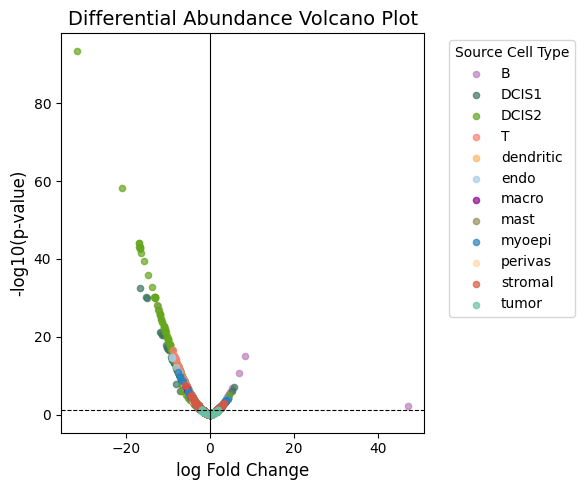

In [51]:
# Compute log fold-change and -log10(p-value) for plotting
# If you already have logFC, skip this step.
diff_abundance_df["logFC"] = diff_abundance_df["stat"]  # or another measure if available
diff_abundance_df["neglog10_pval"] = -np.log10(diff_abundance_df["pval"].clip(lower=1e-300))

# Create the figure
fig, ax = plt.subplots(figsize=(6, 5))

# Plot points per source cell type, colored by col_celltype
for ct, group in diff_abundance_df.groupby("source_ct"):
    color = col_celltype.get(ct, "gray")
    ax.scatter(group["logFC"], group["neglog10_pval"], s=20, color=color, alpha=0.7, label=ct)

# Highlight thresholds (optional)
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8)
ax.axvline(0, color="black", linestyle="-", linewidth=0.8)

# Label axes and title
ax.set_xlabel("log Fold Change", fontsize=12)
ax.set_ylabel("-log10(p-value)", fontsize=12)
ax.set_title("Differential Abundance Volcano Plot", fontsize=14)

# Add legend
ax.legend(title="Source Cell Type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

Let's check the marker RAB11FIP1, which occurs often in DCIS2 that do not border a dendritic cell, but very rarely in those that do border a dendritic cell.

/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `cell_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `table` already exists. Overwriting it in-memory.

INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata/_core/_elements.py:115: UserWarning: Key `transcripts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/g/huber/users/meyerben/notebooks/spatial_transcriptomics/SegTraQ/.venv/lib/python3.13/site-packages/spatialdata_plot/pl/utils.py:775: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is de

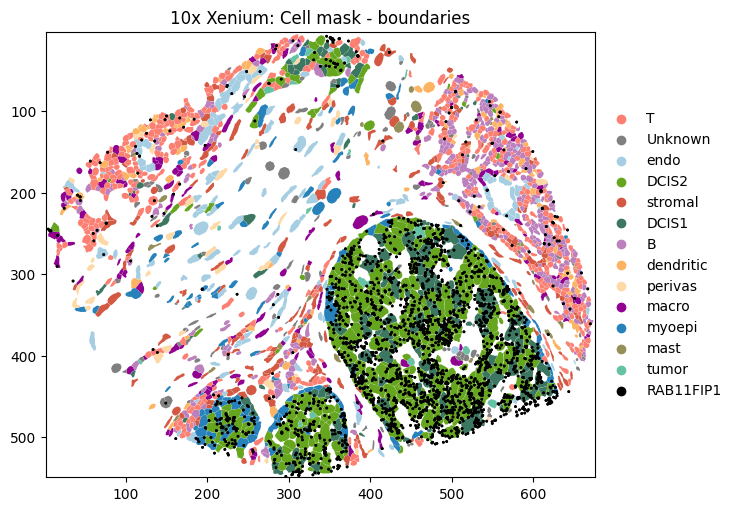

In [59]:
axes = plt.subplots(1, 1, figsize=(10, 5), constrained_layout=True)[1]

# Plot - Cell boundaries
sdata_10x_xenium.pl.render_shapes(
    "cell_boundaries", color="transferred_celltype_plot", palette=cols, groups=labels
).pl.render_points("transcripts", color="feature_name", groups="RAB11FIP1", palette="black").pl.show(
    ax=axes, title="10x Xenium: Cell mask - boundaries", coordinate_systems="global"
)